#파일 입출력

In [87]:
no <- 1:4
name <- c("Apple","Banana","Peach","Berry")
price <- c(500,200,200,50)
qty <- c(5,4,3,2) #따옴표 상관없음

In [88]:
fruit <- data.frame(번호=no,제품=name,금액=price,수량=qty)
fruit

번호,제품,금액,수량
<int>,<chr>,<dbl>,<dbl>
1,Apple,500,5
2,Banana,200,4
3,Peach,200,3
4,Berry,50,2


In [89]:
str(fruit)

'data.frame':	4 obs. of  4 variables:
 $ 번호: int  1 2 3 4
 $ 제품: chr  "Apple" "Banana" "Peach" "Berry"
 $ 금액: num  500 200 200 50
 $ 수량: num  5 4 3 2


In [90]:
#현재 메모리에 있는 변수
ls()

[1] "bar_colors"      "colorDefine"     "Define"          "fruit"          
 [5] "fruit2"          "gdp"             "GDP_ranking"     "GDP_ranking15"  
 [9] "GDP_ranking2"    "iris_setosa"     "iris_versicolor" "iris.test"      
[13] "iris.train"      "irisSamp"        "name"            "no"             
[17] "price"           "qty"             "regionAcc"       "regionAcc.cv"   
[21] "regionAcc.mean"  "regionAcc.sd"    "samp"            "seoul"          
[25] "target"

In [91]:
#메모리 형태로 파일 보관 
save(no, fruit, name, file = "../Data/testFruit.txt")

In [92]:
rm(no, fruit, name)
ls()

[1] "bar_colors"      "colorDefine"     "Define"          "fruit2"         
 [5] "gdp"             "GDP_ranking"     "GDP_ranking15"   "GDP_ranking2"   
 [9] "iris_setosa"     "iris_versicolor" "iris.test"       "iris.train"     
[13] "irisSamp"        "price"           "qty"             "regionAcc"      
[17] "regionAcc.cv"    "regionAcc.mean"  "regionAcc.sd"    "samp"           
[21] "seoul"           "target"

In [93]:
load("../Data/testFruit.txt")
#퍼포먼스가 좋다.
#확장자는 상관이 없다.

In [94]:
fruit

번호,제품,금액,수량
<int>,<chr>,<dbl>,<dbl>
1,Apple,500,5
2,Banana,200,4
3,Peach,200,3
4,Berry,50,2


In [95]:
#fruit를 csv로 저장
write.csv(fruit,"../Data/fruit.csv")

In [96]:
fruit2 <- read.csv("../Data/fruit.csv")

In [97]:
fruit2

X,번호,제품,금액,수량
<int>,<int>,<chr>,<int>,<int>
1,1,Apple,500,5
2,2,Banana,200,4
3,3,Peach,200,3
4,4,Berry,50,2


In [98]:
write.csv(fruit,"../Data/fruit.csv", row.names=F)

In [99]:
read.csv("../Data/fruit.csv")

번호,제품,금액,수량
<int>,<chr>,<int>,<int>
1,Apple,500,5
2,Banana,200,4
3,Peach,200,3
4,Berry,50,2


#세계 GDP 순위 데이터 정제 및 차트 만들기

In [100]:
GDP_ranking <- read.csv("../Data/GDP.csv")
GDP_ranking2 <- GDP_ranking[-c(1:4),c(1,2,4,5)]
head(GDP_ranking2)

,X,Gross.domestic.product.2018,X.2,X.3
,<chr>,<chr>,<chr>,<chr>
5,USA,1,United States,"20,494,100"
6,CHN,2,China,"13,608,152"
7,JPN,3,Japan,"4,970,916"
8,DEU,4,Germany,"3,996,759"
9,GBR,5,United Kingdom,"2,825,208"
10,FRA,6,France,"2,777,535"


In [101]:
#상위 15개국만 선별
GDP_ranking15 <- head(GDP_ranking2,15)
GDP_ranking15

,X,Gross.domestic.product.2018,X.2,X.3
,<chr>,<chr>,<chr>,<chr>
5,USA,1,United States,"20,494,100"
6,CHN,2,China,"13,608,152"
7,JPN,3,Japan,"4,970,916"
8,DEU,4,Germany,"3,996,759"
9,GBR,5,United Kingdom,"2,825,208"
10,FRA,6,France,"2,777,535"
11,IND,7,India,"2,726,323"
12,ITA,8,Italy,"2,073,902"
13,BRA,9,Brazil,"1,868,626"


In [102]:
#컬럼 이름 변경
colnames(GDP_ranking15) <- c("Code", "Ranking","Nation","GDP")
GDP_ranking15

,Code,Ranking,Nation,GDP
,<chr>,<chr>,<chr>,<chr>
5,USA,1,United States,"20,494,100"
6,CHN,2,China,"13,608,152"
7,JPN,3,Japan,"4,970,916"
8,DEU,4,Germany,"3,996,759"
9,GBR,5,United Kingdom,"2,825,208"
10,FRA,6,France,"2,777,535"
11,IND,7,India,"2,726,323"
12,ITA,8,Italy,"2,073,902"
13,BRA,9,Brazil,"1,868,626"


In [103]:
gdp <- GDP_ranking15$GDP
gdp

[1] " 20,494,100 " " 13,608,152 " " 4,970,916 "  " 3,996,759 "  " 2,825,208 " 
 [6] " 2,777,535 "  " 2,726,323 "  " 2,073,902 "  " 1,868,626 "  " 1,712,510 " 
[11] " 1,657,554 "  " 1,619,424 "  " 1,432,195 "  " 1,426,189 "  " 1,223,809 "

In [104]:
#stringr
library(stringr)

In [105]:
str_remove_all(gdp,",")

[1] " 20494100 " " 13608152 " " 4970916 "  " 3996759 "  " 2825208 " 
 [6] " 2777535 "  " 2726323 "  " 2073902 "  " 1868626 "  " 1712510 " 
[11] " 1657554 "  " 1619424 "  " 1432195 "  " 1426189 "  " 1223809 "

In [106]:
gdp <- as.numeric(str_remove_all(gdp,","))
gdp

[1] 20494100 13608152  4970916  3996759  2825208  2777535  2726323  2073902
 [9]  1868626  1712510  1657554  1619424  1432195  1426189  1223809

In [107]:
GDP_ranking15$GDP <-gdp
head(GDP_ranking15)
#하나만 제거 remove

,Code,Ranking,Nation,GDP
,<chr>,<chr>,<chr>,<dbl>
5,USA,1,United States,20494100
6,CHN,2,China,13608152
7,JPN,3,Japan,4970916
8,DEU,4,Germany,3996759
9,GBR,5,United Kingdom,2825208
10,FRA,6,France,2777535


In [108]:
options(warn = -1)
options(repr.plot.width = 15, repr.plot.height = 9)
Sys.setlocale(category = "LC_ALL", locale = "ko_KR.UTF-8")

[1] "ko_KR.UTF-8/ko_KR.UTF-8/ko_KR.UTF-8/C/ko_KR.UTF-8/C.UTF-8"

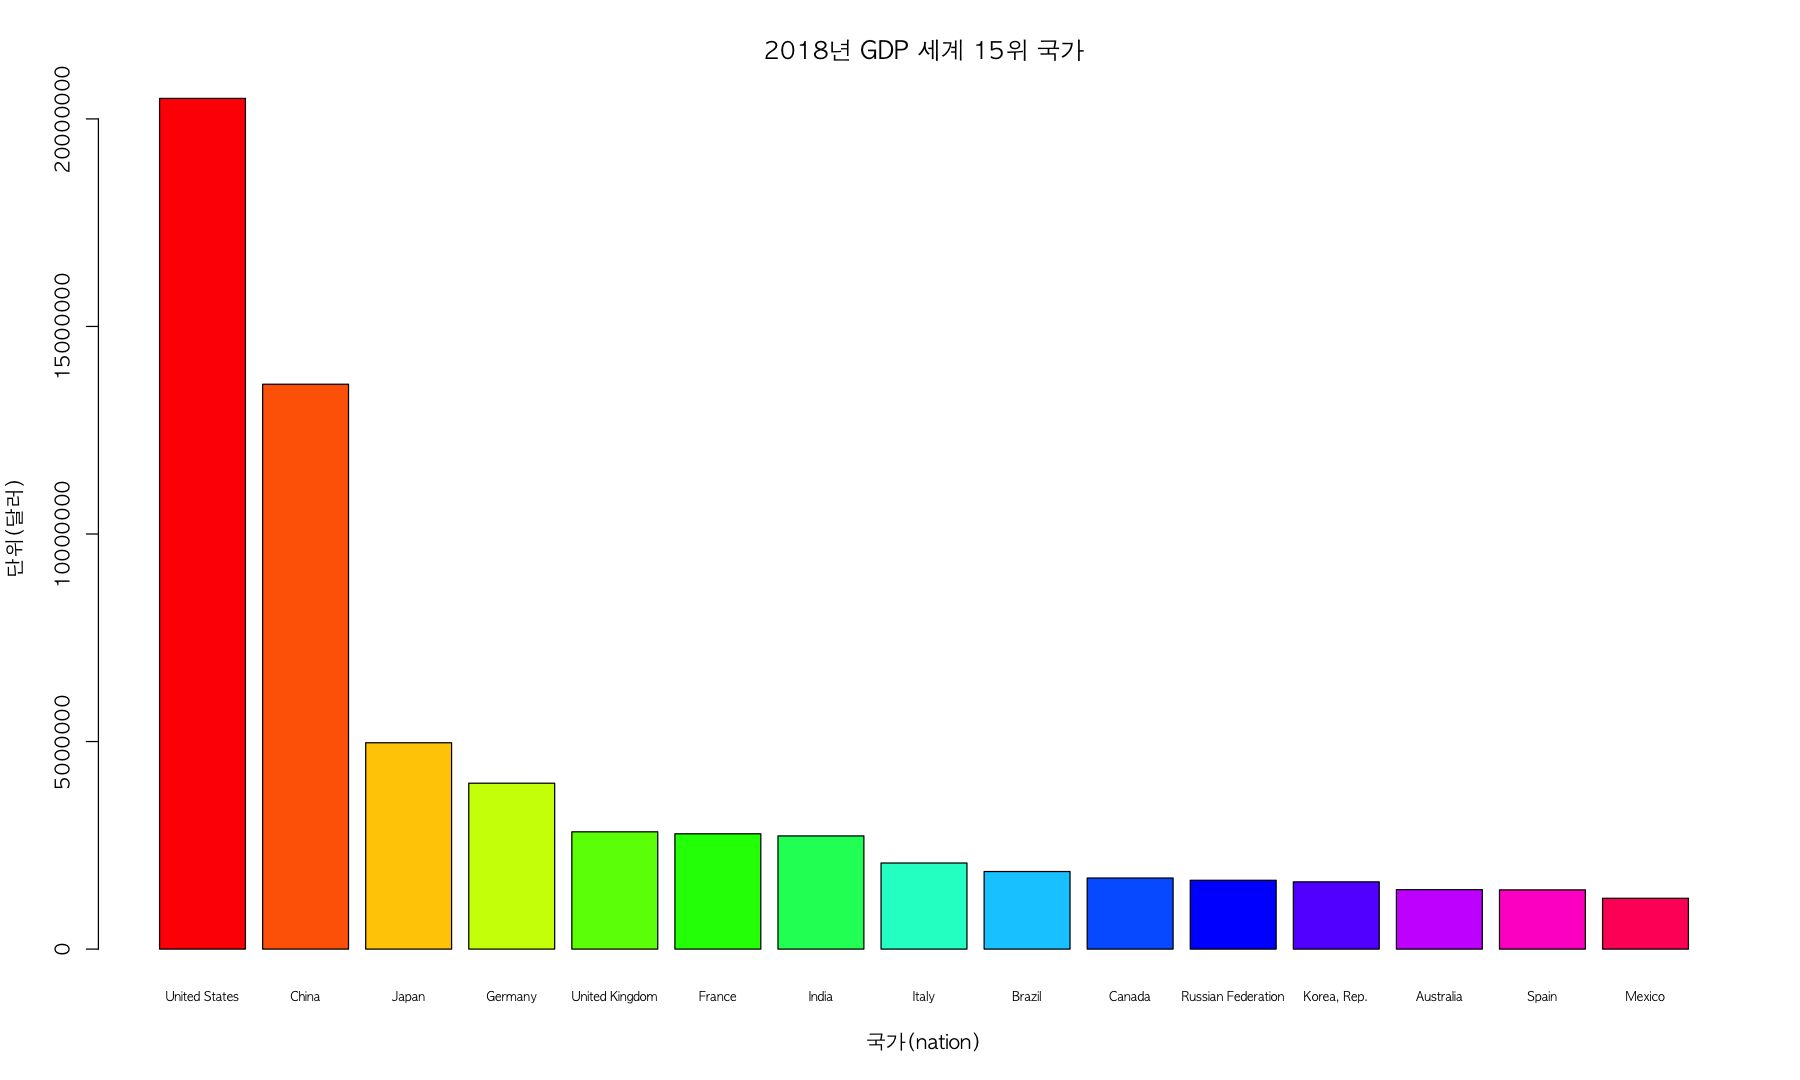

In [109]:
#막대 그래프 시각화
par(family = "AppleGothic", bg='white') #한글,배경색
options(scipen = 100) #지수 없애기

barplot(
    GDP_ranking15$GDP,
    #col = c('red','blue','green')
    #col = c('red')
    col=rainbow(nrow(GDP_ranking15)),
    xlab="국가(nation)",
    ylab="단위(달러)",
    main="2018년 GDP 세계 15위 국가",#타이틀
    names=GDP_ranking15$Nation,#Data
    cex.names=0.6 #폰트크기 기본1
)#시각화 R #인구수와 비례함

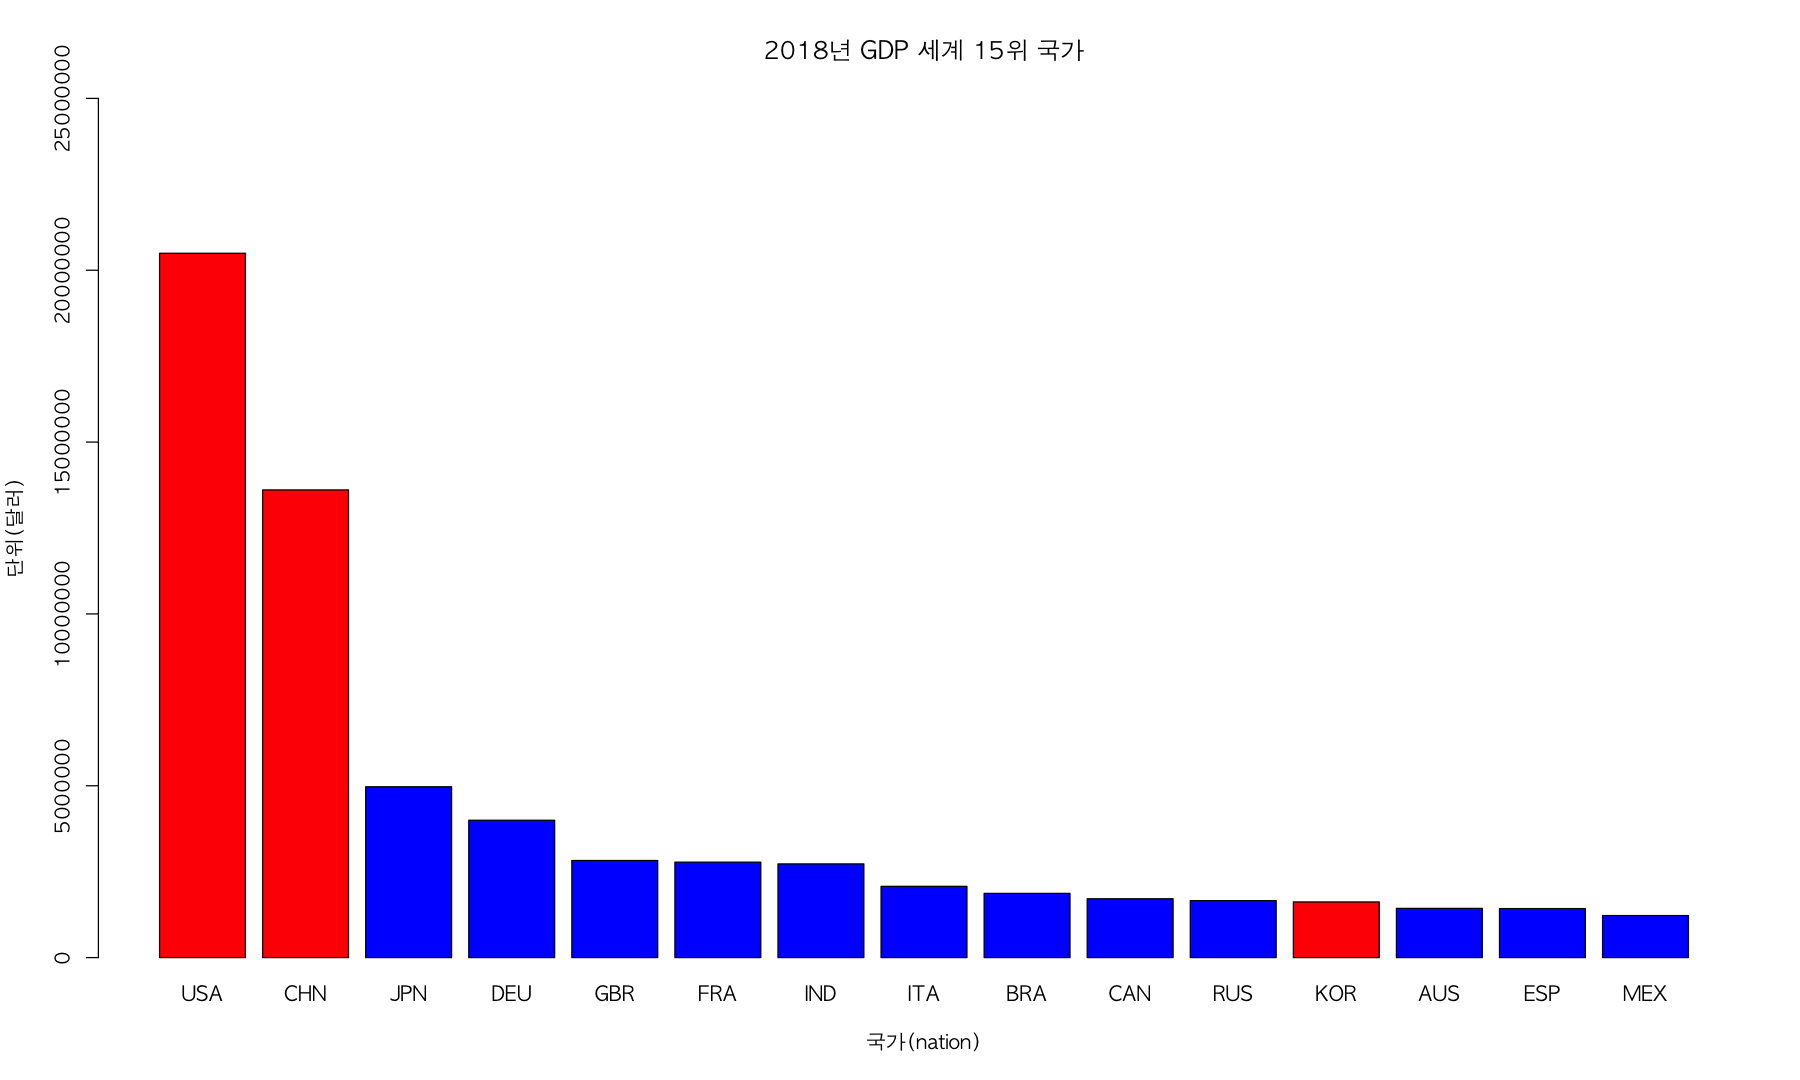

In [110]:
# 막대 그래프 시각화
target <- c("USA","CHN","KOR")
bar_colors <- ifelse(GDP_ranking15$Code %in% target, "red", "blue")
par(family = "AppleGothic" , bg = 'white') # 배경색
options(scipen = 100) # 지수 없애기

barplot(
    GDP_ranking15$GDP,
    col = bar_colors,  # 색깔변경
    xlab = "국가(nation)",
    ylab = "단위(달러)",
    main = "2018년 GDP 세계 15위 국가",
    names = GDP_ranking15$Code,
    cex.names = 1,
    ylim=c(0,25000000)
)

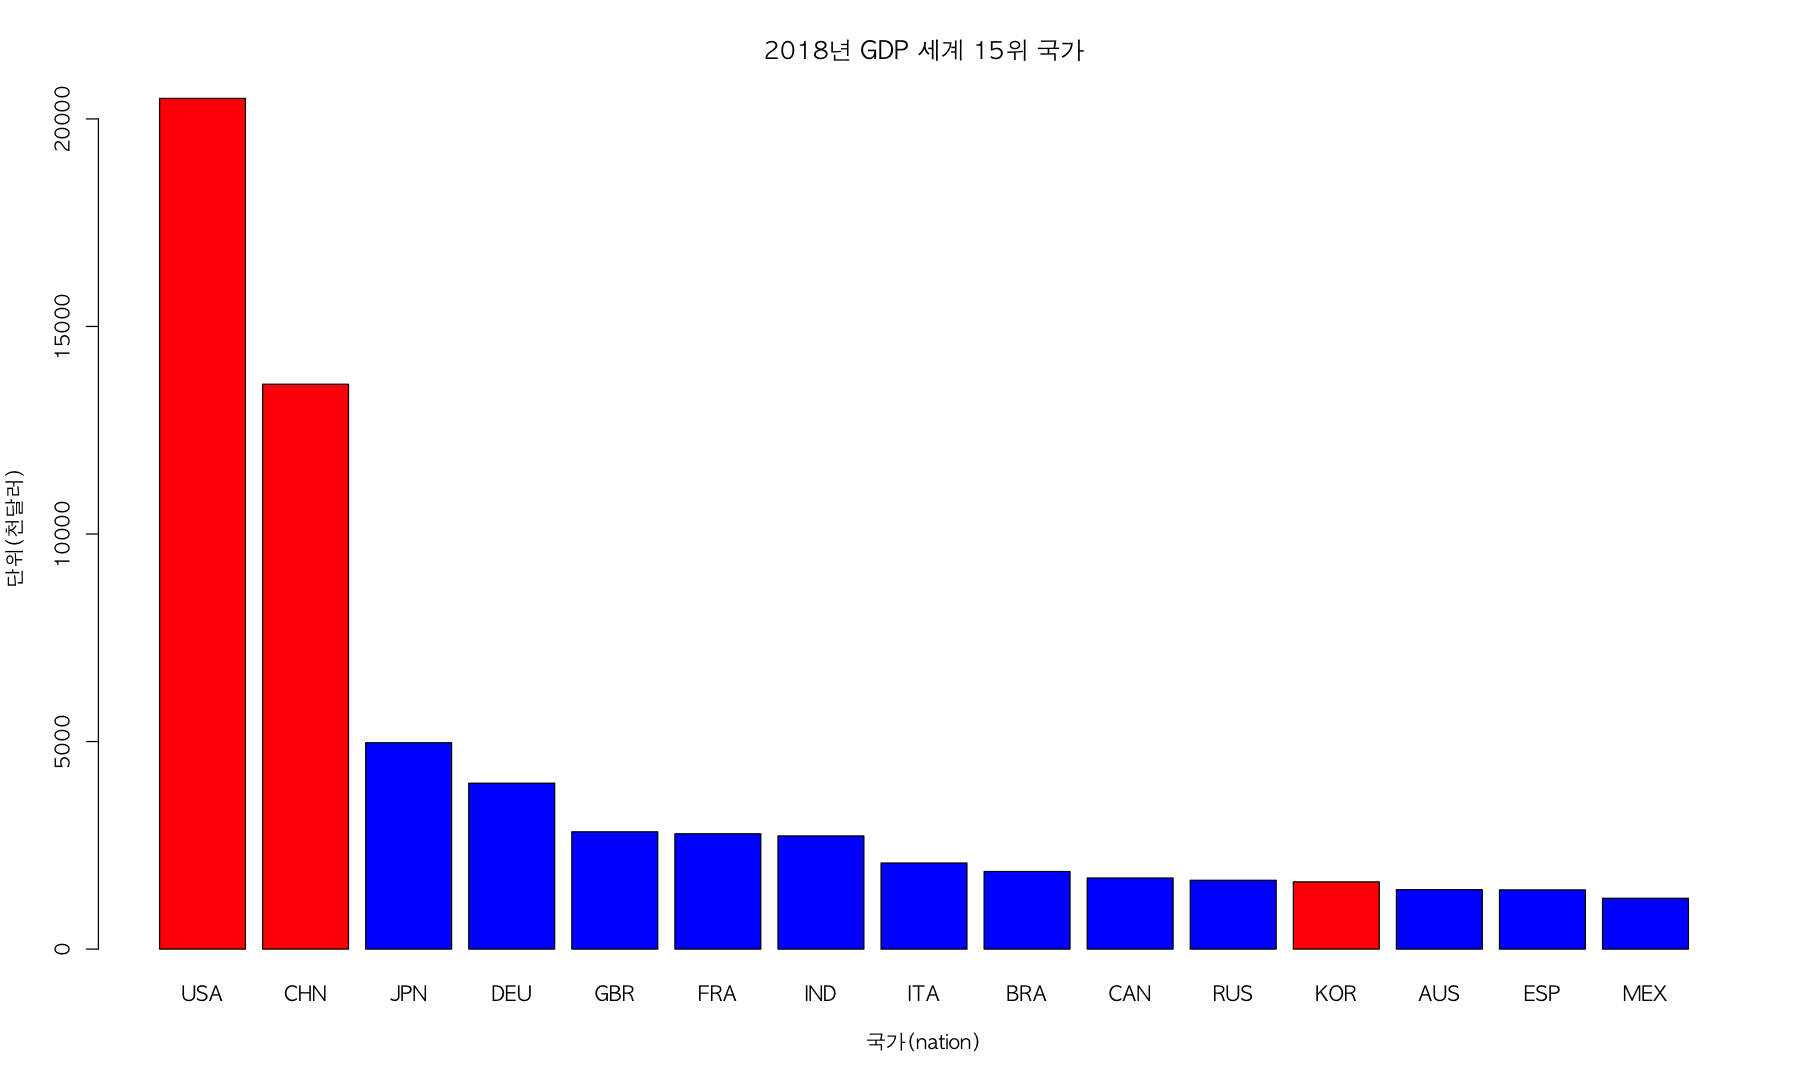

In [111]:
# 막대 그래프 시각화
target <- c("USA","CHN","KOR")
bar_colors <- ifelse(GDP_ranking15$Code %in% target, "red", "blue")
par(family = "AppleGothic" , bg = 'white') # 배경색
options(scipen = 100) # 지수 없애기

barplot(
    GDP_ranking15$GDP /1000, 
    col = bar_colors,  # 색깔변경
    xlab = "국가(nation)",
    ylab = "단위(천달러)",
    main = "2018년 GDP 세계 15위 국가",
    names = GDP_ranking15$Code,
    cex.names = 1
)

In [112]:
ifelse(GDP_ranking15$Code == c("USA","CHN","KOR"),1,0)

[1] 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0

In [113]:
colorDefine <- function(){
    return(ifelse(
        ifelse(GDP_ranking15$Code == c("USA"),1,0)+
        ifelse(GDP_ranking15$Code == c("CHN"),1,0)+
        ifelse(GDP_ranking15$Code == c("KOR"),1,0)==1,"red","blue"

        ))
}

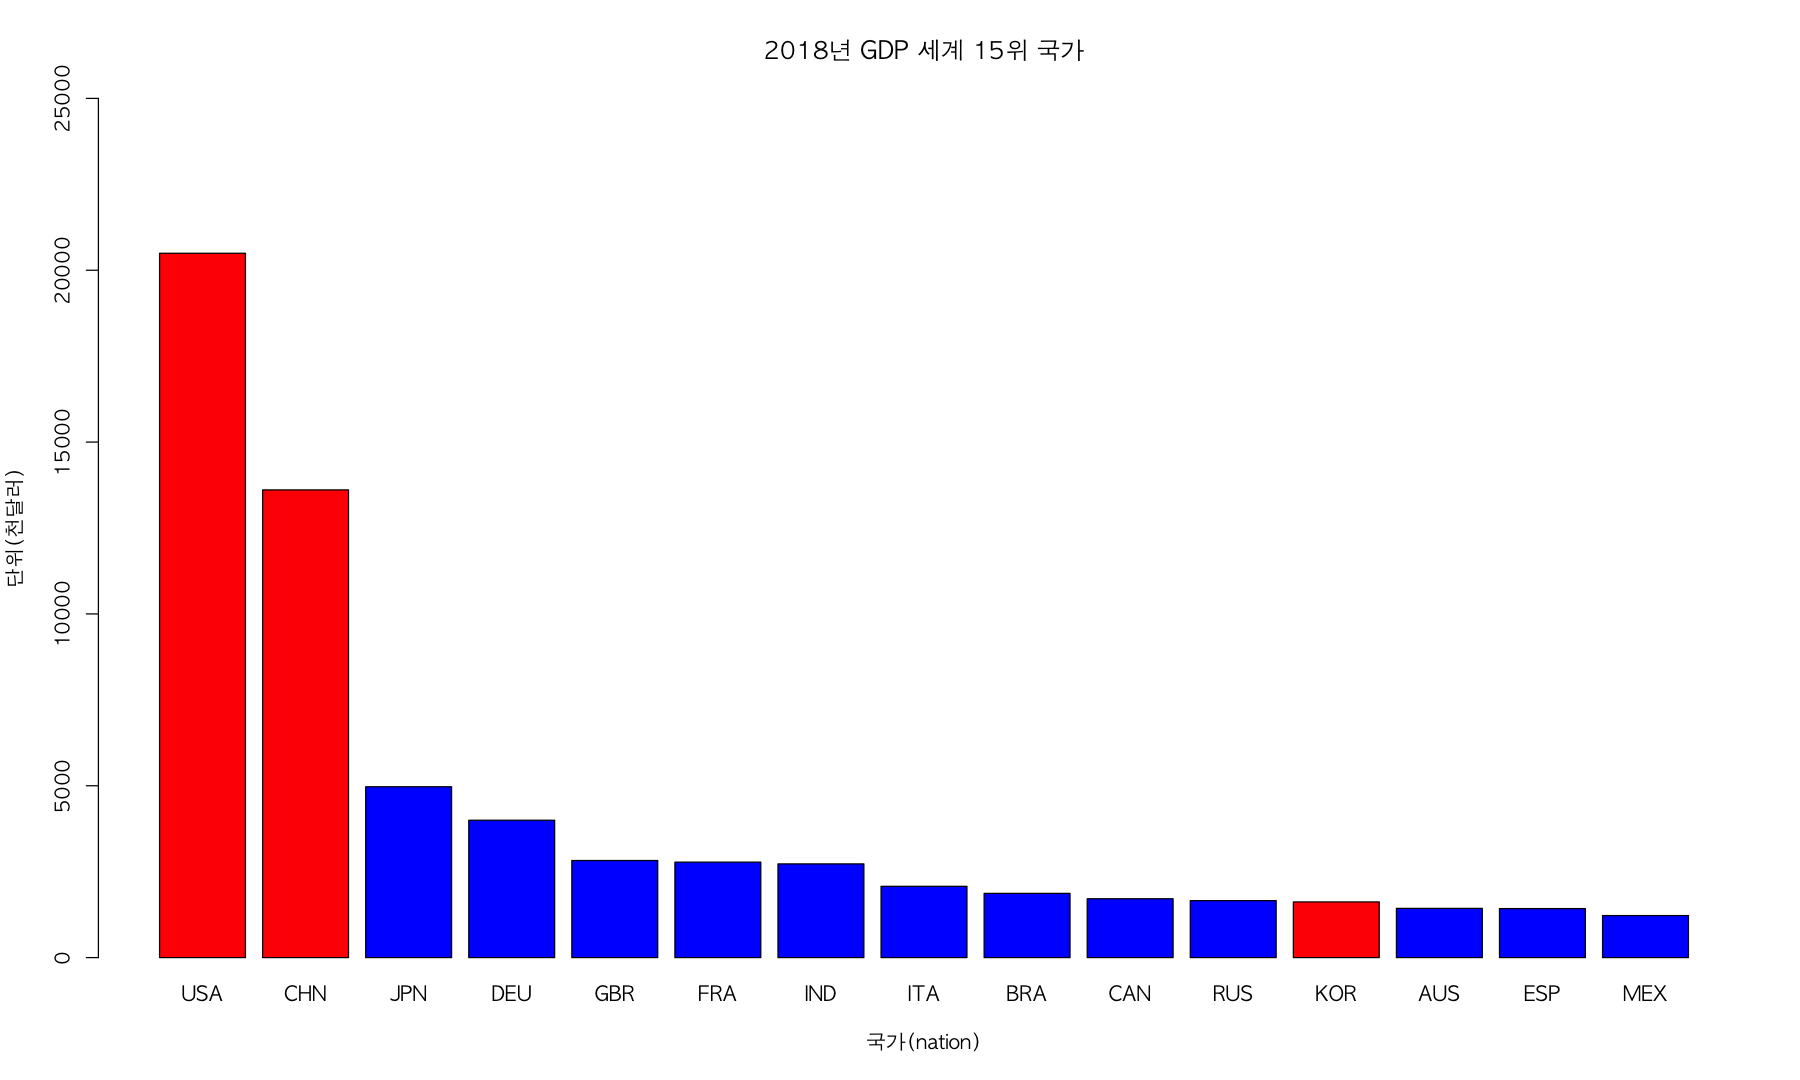

In [114]:
# 막대 그래프 시각화


par(family = "AppleGothic" , bg = 'white') # 배경색
options(scipen = 100) # 지수 없애기

barplot(
    GDP_ranking15$GDP/1000,
    col = colorDefine(),  # 색깔변경
    xlab = "국가(nation)",
    ylab = "단위(천달러)",
    main = "2018년 GDP 세계 15위 국가",
    names = GDP_ranking15$Code,
    cex.names = 1,
    ylim=c(0,25000)
)

In [115]:
#Ex:GDP를 1000으로 나눈 값중 GDP가 3000이상인 국가만 빨간색으로 나머지는 파란색으로 표시하기
Define <- function(){
  return(
    ifelse(
      GDP_ranking15$GDP / 1000 >= 3000,
      "red",
      "blue"
    )
  )
}

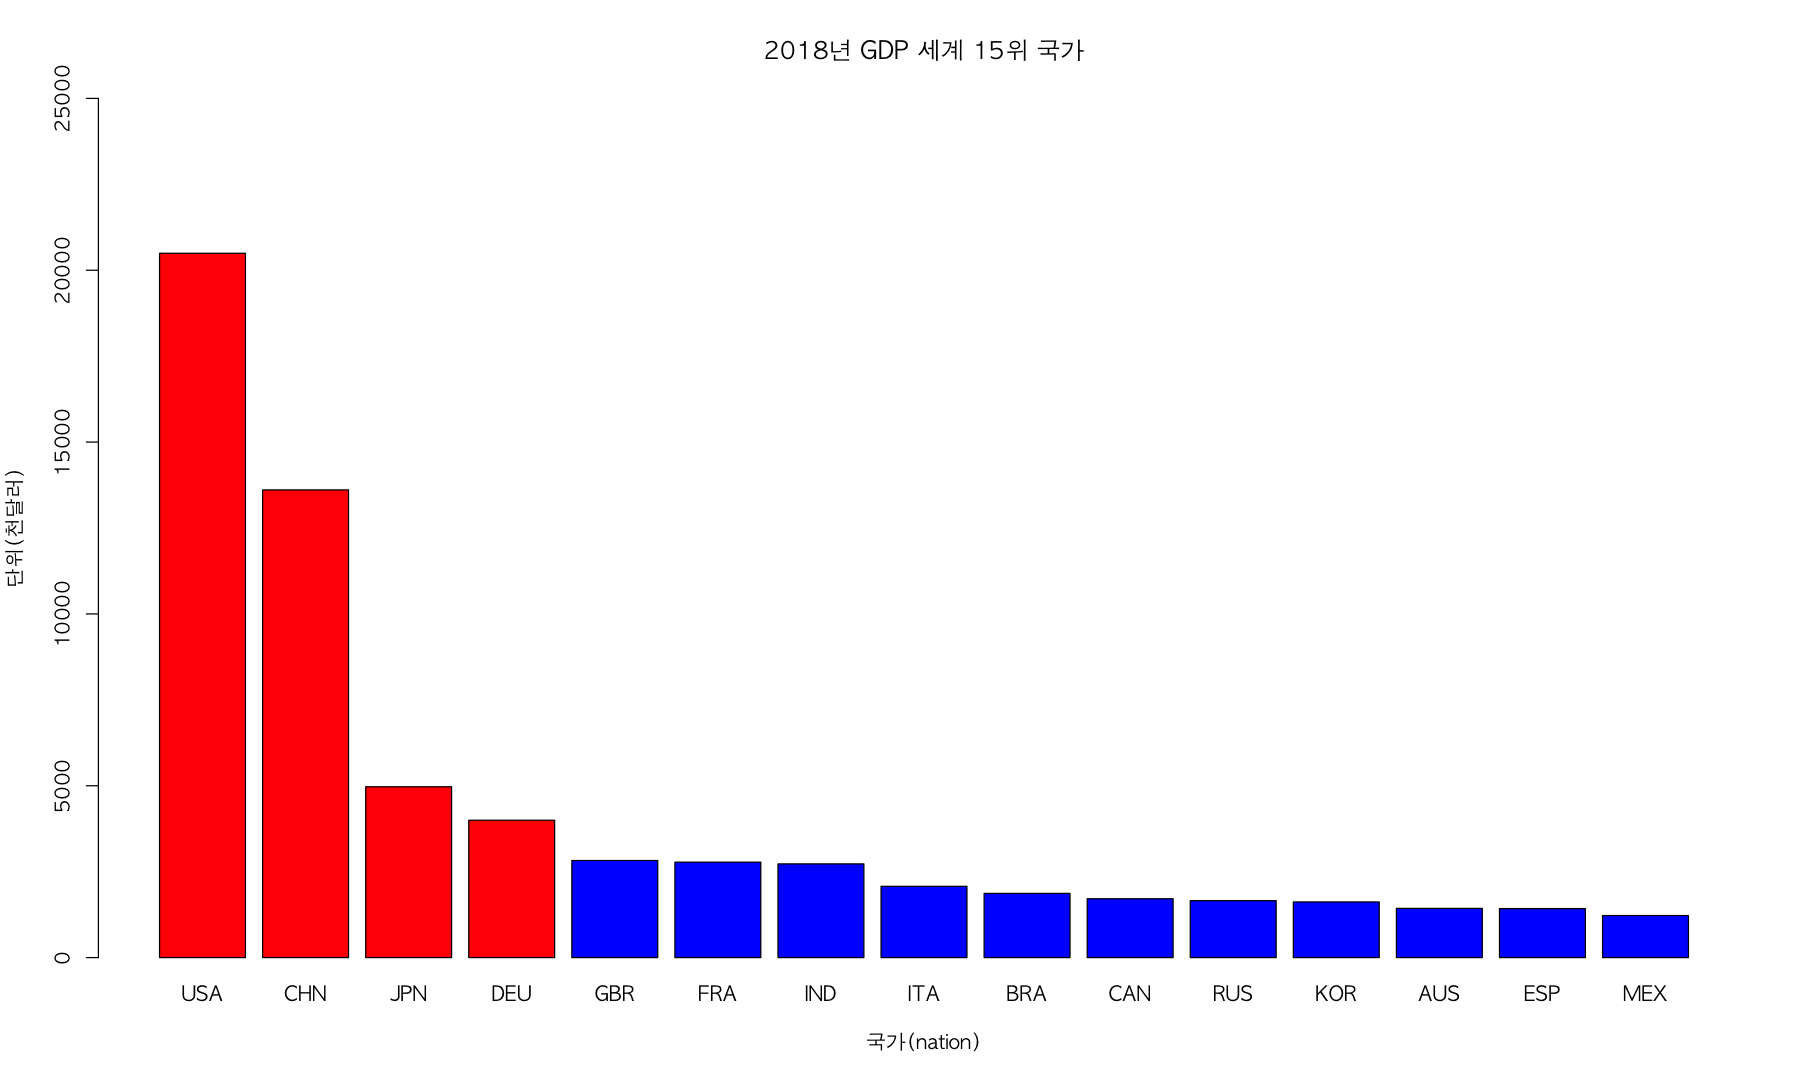

In [116]:
# 막대 그래프 시각화

par(family = "AppleGothic" , bg = 'white') # 배경색
options(scipen = 100) # 지수 없애기

barplot(
    GDP_ranking15$GDP/1000,
    col =  ifelse(
      GDP_ranking15$GDP / 1000 >= 3000,
      "red",
      "blue"
    ),  # 색깔변경
    xlab = "국가(nation)",
    ylab = "단위(천달러)",
    main = "2018년 GDP 세계 15위 국가",
    names = GDP_ranking15$Code,
    cex.names = 1,
    ylim=c(0,25000)
)

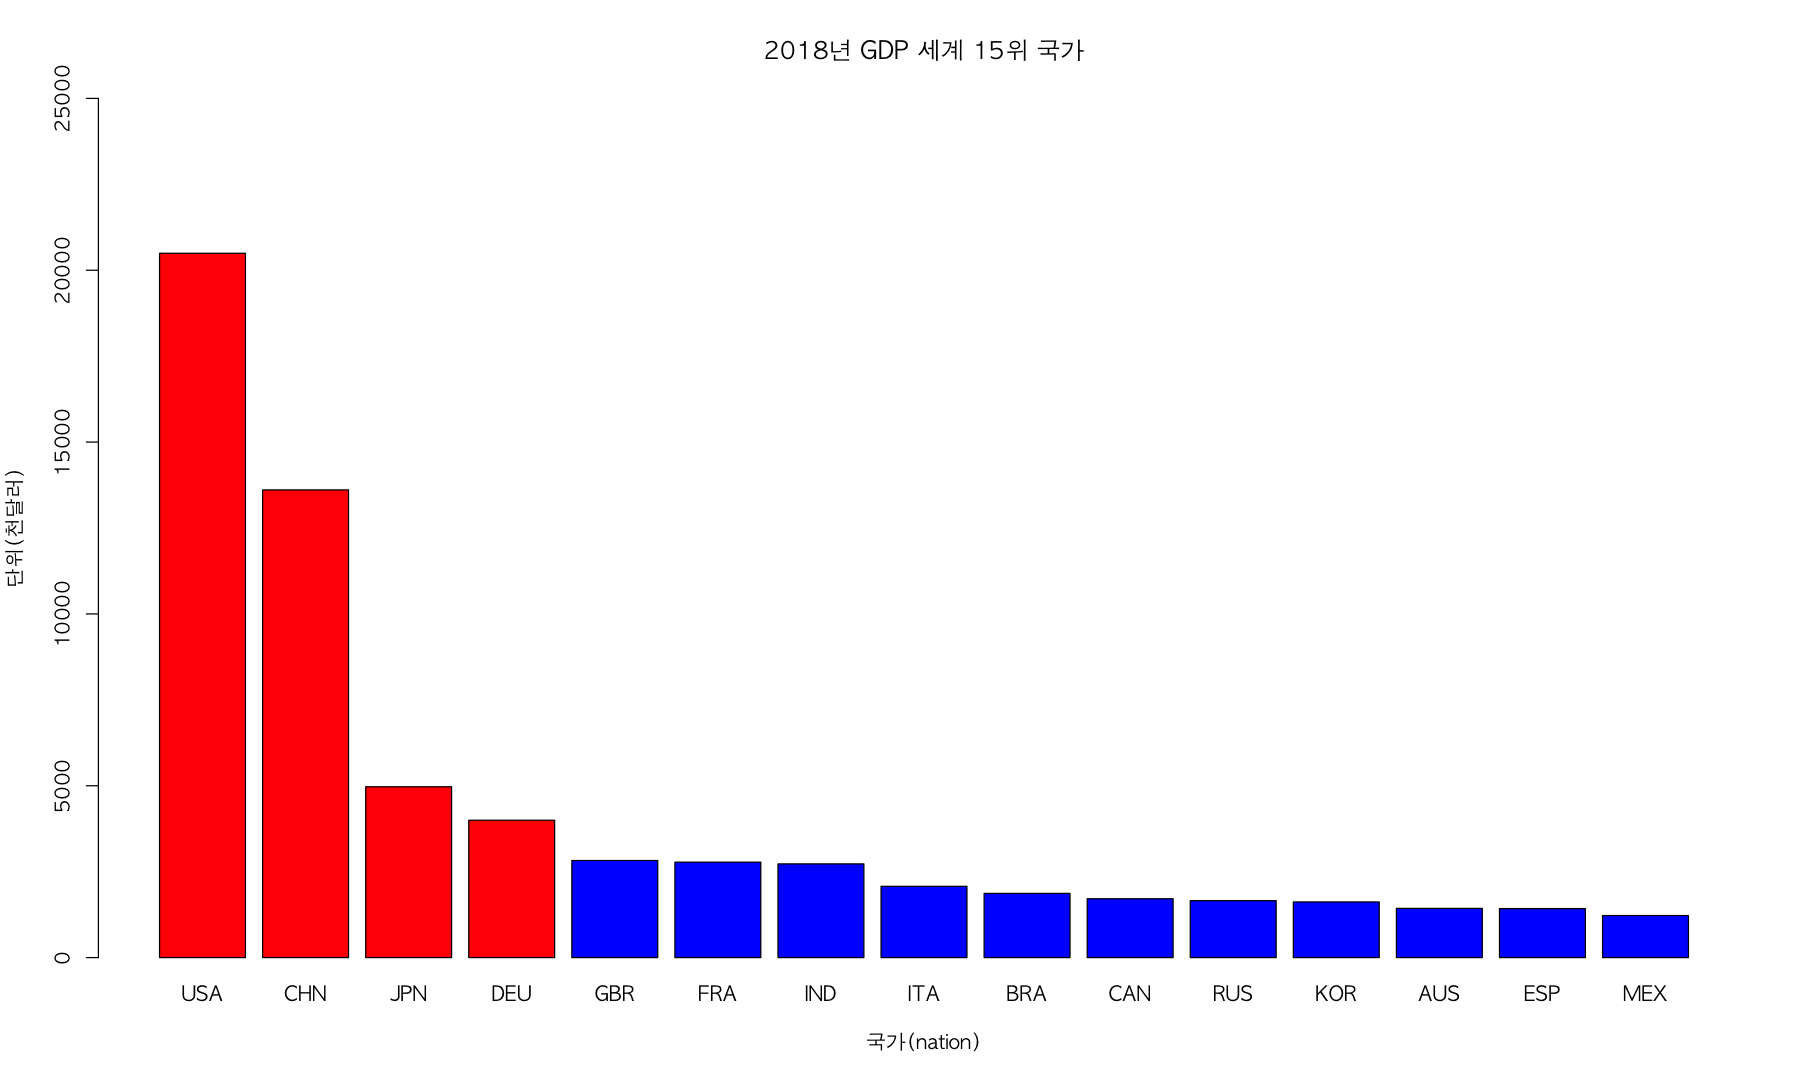

In [117]:
# 막대 그래프 시각화

par(family = "AppleGothic" , bg = 'white') # 배경색
options(scipen = 100) # 지수 없애기

barplot(
    GDP_ranking15$GDP/1000,
    col = Define(),  # 색깔변경
    xlab = "국가(nation)",
    ylab = "단위(천달러)",
    main = "2018년 GDP 세계 15위 국가",
    names = GDP_ranking15$Code,#벡터 이름
    cex.names = 1,
    ylim=c(0,25000)
)

#데이터 처리

In [118]:
install.packages("dplyr")


The downloaded binary packages are in
	/var/folders/bn/b43j8ymd33x1z80xxsm606h40000gn/T//RtmpZuu6nZ/downloaded_packages


In [119]:
library(dplyr)#정렬 패키지

In [120]:
#데이터 정렬
#Sepal.Length 기준으로 오름차순 정렬
iris

Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
<dbl>,<dbl>,<dbl>,<dbl>,<fct>
5.1,3.5,1.4,0.2,setosa
4.9,3.0,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5.0,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5.0,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa


In [121]:
head(arrange(iris,Sepal.Length))

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,4.3,3.0,1.1,0.1,setosa
2,4.4,2.9,1.4,0.2,setosa
3,4.4,3.0,1.3,0.2,setosa
4,4.4,3.2,1.3,0.2,setosa
5,4.5,2.3,1.3,0.3,setosa
6,4.6,3.1,1.5,0.2,setosa


In [122]:
# Sepal.Length기준으로 오름차순 정렬후 Sepal.Lentg와 Sepal.Width만 보기
head(arrange(iris[,1:2], Sepal.Length))

,Sepal.Length,Sepal.Width
,<dbl>,<dbl>
1,4.3,3.0
2,4.4,2.9
3,4.4,3.0
4,4.4,3.2
5,4.5,2.3
6,4.6,3.1


In [123]:
#Sepal.Length기준으로 정렬후 동일한 크기를 가진 데이터 발생시 Petal.Length기준으로 오름차순 정렬하기
head(arrange(iris,Sepal.Length,Petal.Length))

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,4.3,3.0,1.1,0.1,setosa
2,4.4,3.0,1.3,0.2,setosa
3,4.4,3.2,1.3,0.2,setosa
4,4.4,2.9,1.4,0.2,setosa
5,4.5,2.3,1.3,0.3,setosa
6,4.6,3.6,1.0,0.2,setosa


In [124]:
#Sepal.Length기준으로 내림차순 정렬
head(arrange(iris,desc(Sepal.Length)))#함수

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,7.9,3.8,6.4,2.0,virginica
2,7.7,3.8,6.7,2.2,virginica
3,7.7,2.6,6.9,2.3,virginica
4,7.7,2.8,6.7,2.0,virginica
5,7.7,3.0,6.1,2.3,virginica
6,7.6,3.0,6.6,2.1,virginica


In [125]:
#랜덤 샘플링(중복값을 허용하지 않음)
sample(1:45,6)#머신러닝 추출

[1]  9 43 19 22 40 29

In [126]:
samp <- sample(1:nrow(iris), nrow(iris)*0.7)
samp#벡터

[1] 109 144  38  88 107  70 119  79  86  71 123 140  99  26  22  28  98 101
 [19]  40  67  72 121  68 120  84  83 122 141  96  17  25  35   2 133  47 116
 [37]  30  10 136  57  49 138  89  80  73  20  12  37  81 131 115 142 148  82
 [55]  94  19  18  23  31   6   7 130   4  43  61  15 129  87  39  42 149  58
 [73] 124  11  56 108   8 112 102  63  75 105  33 150  59   3  36  64  77 146
 [91] 128  51  29   1 114 135  44  95 113  21  13 104 143  92  60

In [127]:
irisSamp<- iris[samp,]
head(irisSamp)#rownames번호 중요


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
109,6.7,2.5,5.8,1.8,virginica
144,6.8,3.2,5.9,2.3,virginica
38,4.9,3.6,1.4,0.1,setosa
88,6.3,2.3,4.4,1.3,versicolor
107,4.9,2.5,4.5,1.7,virginica
70,5.6,2.5,3.9,1.1,versicolor


In [128]:
#sampling한 Species의 빈도수 확인
table(irisSamp$Species)


    setosa versicolor  virginica 
        37         33         35 

In [129]:
samp<-c(sample(1:50,35),sample(51:100,35),sample(101:150,35))
#서울 강원도 제주도 통계청에서 이용
irisSamp<-iris[samp,]
table(irisSamp$Species)


    setosa versicolor  virginica 
        35         35         35 

In [130]:
##########################
#train,test로 분리하기
iris.train <- iris[samp,]
iris.test <- iris[-samp,]
############################

In [131]:
summary(iris.train)
summary(iris.test)
#Median을 비교:정규분포

  Sepal.Length    Sepal.Width    Petal.Length    Petal.Width          Species  
 Min.   :4.300   Min.   :2.00   Min.   :1.000   Min.   :0.100   setosa    :35  
 1st Qu.:5.100   1st Qu.:2.80   1st Qu.:1.600   1st Qu.:0.300   versicolor:35  
 Median :5.800   Median :3.00   Median :4.300   Median :1.300   virginica :35  
 Mean   :5.842   Mean   :3.05   Mean   :3.753   Mean   :1.198                  
 3rd Qu.:6.400   3rd Qu.:3.40   3rd Qu.:5.100   3rd Qu.:1.800                  
 Max.   :7.900   Max.   :4.10   Max.   :6.900   Max.   :2.500                  

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.400   Min.   :2.200   Min.   :1.300   Min.   :0.200  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.500   1st Qu.:0.300  
 Median :5.800   Median :3.100   Median :4.400   Median :1.300  
 Mean   :5.847   Mean   :3.073   Mean   :3.769   Mean   :1.202  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.700   Max.   :4.400   Max.   :6.700   Max.   :2.500  
       Species  
 setosa    :15  
 versicolor:15  
 virginica :15  
                
                
                

In [132]:
#Machine Learning
set.seed(1234)#똑같이 맞춰줌
samp<-c(sample(1:50,35),sample(51:100,35),sample(101:150,35))
irisSamp<-iris[samp,]
table(irisSamp$Species)


    setosa versicolor  virginica 
        35         35         35 

In [133]:
iris.train <- iris[samp,]
iris.test <- iris[-samp,]

In [134]:
summary(iris.train)
summary(iris.test)
#R은 펙터이기때문에 문자도 알려줌(통계언어)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width         Species  
 Min.   :4.300   Min.   :2.200   Min.   :1.100   Min.   :0.10   setosa    :35  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.600   1st Qu.:0.30   versicolor:35  
 Median :5.800   Median :3.000   Median :4.300   Median :1.30   virginica :35  
 Mean   :5.847   Mean   :3.042   Mean   :3.749   Mean   :1.19                  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.80                  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.50                  

  Sepal.Length    Sepal.Width     Petal.Length   Petal.Width          Species  
 Min.   :4.400   Min.   :2.000   Min.   :1.00   Min.   :0.100   setosa    :15  
 1st Qu.:5.100   1st Qu.:2.800   1st Qu.:1.60   1st Qu.:0.300   versicolor:15  
 Median :5.800   Median :3.100   Median :4.70   Median :1.400   virginica :15  
 Mean   :5.836   Mean   :3.093   Mean   :3.78   Mean   :1.222                  
 3rd Qu.:6.500   3rd Qu.:3.400   3rd Qu.:5.10   3rd Qu.:1.900                  
 Max.   :7.700   Max.   :4.100   Max.   :6.70   Max.   :2.500                  

In [135]:
#모집단에서 필요한 데이터만 추출하기(부분집합:subset)
#iris에서 Species가 setosa인것만 추출하여 iris_setosa라는 데이터프레임 생성

iris_setosa<-subset(iris, Species == 'setosa')
head(iris_setosa)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


In [136]:
str(iris_setosa)
#Factor가 3개이다.

'data.frame':	50 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...


In [137]:
#factor조정
iris_setosa$Species <- factor(iris_setosa$Species)
str(iris_setosa)#factor함수로 재구성 3->1

'data.frame':	50 obs. of  5 variables:
 $ Sepal.Length: num  5.1 4.9 4.7 4.6 5 5.4 4.6 5 4.4 4.9 ...
 $ Sepal.Width : num  3.5 3 3.2 3.1 3.6 3.9 3.4 3.4 2.9 3.1 ...
 $ Petal.Length: num  1.4 1.4 1.3 1.5 1.4 1.7 1.4 1.5 1.4 1.5 ...
 $ Petal.Width : num  0.2 0.2 0.2 0.2 0.2 0.4 0.3 0.2 0.2 0.1 ...
 $ Species     : Factor w/ 1 level "setosa": 1 1 1 1 1 1 1 1 1 1 ...


In [138]:
#Ex : iris에서 Species가 vergicolor인것만 추출하여 iris_versicolor라는 데이터 프레임 만들기
iris_versicolor<-subset(iris, Species == 'versicolor')
head(iris_versicolor)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
51,7.0,3.2,4.7,1.4,versicolor
52,6.4,3.2,4.5,1.5,versicolor
53,6.9,3.1,4.9,1.5,versicolor
54,5.5,2.3,4.0,1.3,versicolor
55,6.5,2.8,4.6,1.5,versicolor
56,5.7,2.8,4.5,1.3,versicolor


In [139]:
str(iris_versicolor)

'data.frame':	50 obs. of  5 variables:
 $ Sepal.Length: num  7 6.4 6.9 5.5 6.5 5.7 6.3 4.9 6.6 5.2 ...
 $ Sepal.Width : num  3.2 3.2 3.1 2.3 2.8 2.8 3.3 2.4 2.9 2.7 ...
 $ Petal.Length: num  4.7 4.5 4.9 4 4.6 4.5 4.7 3.3 4.6 3.9 ...
 $ Petal.Width : num  1.4 1.5 1.5 1.3 1.5 1.3 1.6 1 1.3 1.4 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 2 2 2 2 2 2 2 2 2 2 ...


In [140]:
iris_versicolor$Species <- factor(iris_versicolor$Species)
str(iris_versicolor)

'data.frame':	50 obs. of  5 variables:
 $ Sepal.Length: num  7 6.4 6.9 5.5 6.5 5.7 6.3 4.9 6.6 5.2 ...
 $ Sepal.Width : num  3.2 3.2 3.1 2.3 2.8 2.8 3.3 2.4 2.9 2.7 ...
 $ Petal.Length: num  4.7 4.5 4.9 4 4.6 4.5 4.7 3.3 4.6 3.9 ...
 $ Petal.Width : num  1.4 1.5 1.5 1.3 1.5 1.3 1.6 1 1.3 1.4 ...
 $ Species     : Factor w/ 1 level "versicolor": 1 1 1 1 1 1 1 1 1 1 ...


In [141]:
rownames(iris_versicolor)<-c()
head(iris_versicolor)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,7.0,3.2,4.7,1.4,versicolor
2,6.4,3.2,4.5,1.5,versicolor
3,6.9,3.1,4.9,1.5,versicolor
4,5.5,2.3,4.0,1.3,versicolor
5,6.5,2.8,4.6,1.5,versicolor
6,5.7,2.8,4.5,1.3,versicolor


In [142]:
#Ex : iris에서 Species가 setosa이고 Sepal.Length가 5보다 큰 자료만 추출
iris_setosa<-subset(iris, Species == 'setosa' & Sepal.Length >5)
head(iris_setosa)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
11,5.4,3.7,1.5,0.2,setosa
15,5.8,4.0,1.2,0.2,setosa
16,5.7,4.4,1.5,0.4,setosa
17,5.4,3.9,1.3,0.4,setosa


In [143]:
str(iris_setosa)

'data.frame':	22 obs. of  5 variables:
 $ Sepal.Length: num  5.1 5.4 5.4 5.8 5.7 5.4 5.1 5.7 5.1 5.4 ...
 $ Sepal.Width : num  3.5 3.9 3.7 4 4.4 3.9 3.5 3.8 3.8 3.4 ...
 $ Petal.Length: num  1.4 1.7 1.5 1.2 1.5 1.3 1.4 1.7 1.5 1.7 ...
 $ Petal.Width : num  0.2 0.4 0.2 0.2 0.4 0.4 0.3 0.3 0.3 0.2 ...
 $ Species     : Factor w/ 3 levels "setosa","versicolor",..: 1 1 1 1 1 1 1 1 1 1 ...


In [144]:
iris_setosa$Species <- factor(iris_setosa$Species)
str(iris_setosa)

'data.frame':	22 obs. of  5 variables:
 $ Sepal.Length: num  5.1 5.4 5.4 5.8 5.7 5.4 5.1 5.7 5.1 5.4 ...
 $ Sepal.Width : num  3.5 3.9 3.7 4 4.4 3.9 3.5 3.8 3.8 3.4 ...
 $ Petal.Length: num  1.4 1.7 1.5 1.2 1.5 1.3 1.4 1.7 1.5 1.7 ...
 $ Petal.Width : num  0.2 0.4 0.2 0.2 0.4 0.4 0.3 0.3 0.3 0.2 ...
 $ Species     : Factor w/ 1 level "setosa": 1 1 1 1 1 1 1 1 1 1 ...


In [145]:
head(iris_setosa)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
11,5.4,3.7,1.5,0.2,setosa
15,5.8,4.0,1.2,0.2,setosa
16,5.7,4.4,1.5,0.4,setosa
17,5.4,3.9,1.3,0.4,setosa


In [146]:
# rownames(iris_setosa) <- 1:nrow(iris_setosa)

In [147]:
#subset으로 컬럼 지우기
subset(iris, select = -Species)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
,<dbl>,<dbl>,<dbl>,<dbl>
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2
6,5.4,3.9,1.7,0.4
7,4.6,3.4,1.4,0.3
8,5.0,3.4,1.5,0.2
9,4.4,2.9,1.4,0.2


그룹연산 함수

In [148]:
aggregate(Sepal.Width ~ Species, iris, mean)#species 기준

Species,Sepal.Width
<fct>,<dbl>
setosa,3.428
versicolor,2.770
virginica,2.974


In [149]:
aggregate(Sepal.Width ~ Species, iris, sum)#species 기준

Species,Sepal.Width
<fct>,<dbl>
setosa,171.4
versicolor,138.5
virginica,148.7


In [150]:
seoul <- read.csv("../Data/newSeoul.csv")

In [151]:
str(seoul)

'data.frame':	2700 obs. of  6 variables:
 $ 년도    : int  2011 2011 2011 2011 2011 2011 2011 2011 2011 2011 ...
 $ 월      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ 자치구명: chr  "종로구" "종로구" "종로구" "종로구" ...
 $ 발생건수: int  115 99 116 110 122 116 103 122 121 135 ...
 $ 사망자수: int  2 0 0 1 0 3 1 1 2 2 ...
 $ 부상자수: int  165 134 162 153 157 163 154 171 166 193 ...


In [152]:
summary(seoul)

      년도            월          자치구명            발생건수    
 Min.   :2011   Min.   : 1.00   Length:2700        Min.   : 45.0  
 1st Qu.:2013   1st Qu.: 3.75   Class :character   1st Qu.:100.0  
 Median :2015   Median : 6.50   Mode  :character   Median :122.0  
 Mean   :2015   Mean   : 6.50                      Mean   :133.3  
 3rd Qu.:2017   3rd Qu.: 9.25                      3rd Qu.:149.0  
 Max.   :2019   Max.   :12.00                      Max.   :383.0  
    사망자수         부상자수    
 Min.   : 0.000   Min.   : 55.0  
 1st Qu.: 0.000   1st Qu.:138.0  
 Median : 1.000   Median :168.0  
 Mean   : 1.207   Mean   :187.4  
 3rd Qu.: 2.000   3rd Qu.:208.0  
 Max.   :10.000   Max.   :552.0  

In [153]:
#NA확인
is.na(seoul)
sum(is.na(seoul))
table(is.na(seoul))

년도,월,자치구명,발생건수,사망자수,부상자수
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE
FALSE,FALSE,FALSE,FALSE,FALSE,FALSE


[1] 0


FALSE 
16200 

In [154]:
head(seoul)

,년도,월,자치구명,발생건수,사망자수,부상자수
,<int>,<int>,<chr>,<int>,<int>,<int>
1,2011,1,종로구,115,2,165
2,2011,2,종로구,99,0,134
3,2011,3,종로구,116,0,162
4,2011,4,종로구,110,1,153
5,2011,5,종로구,122,0,157
6,2011,6,종로구,116,3,163


In [155]:
range(seoul$'년도')

[1] 2011 2019

In [156]:
table(seoul$'년도')


2011 2012 2013 2014 2015 2016 2017 2018 2019 
 300  300  300  300  300  300  300  300  300 

In [157]:
range(seoul$'월')
table(seoul$'월')

[1]  1 12


  1   2   3   4   5   6   7   8   9  10  11  12 
225 225 225 225 225 225 225 225 225 225 225 225 

In [158]:
range(seoul$'자치구명')

[1] "강남구" "중랑구"

In [159]:
length(unique(seoul$'자치구명'))
table(seoul$'자치구명')

[1] 25


  강남구   강동구   강북구   강서구   관악구   광진구   구로구   금천구 
     108      108      108      108      108      108      108      108 
  노원구   도봉구 동대문구   동작구   마포구 서대문구   서초구   성동구 
     108      108      108      108      108      108      108      108 
  성북구   송파구   양천구 영등포구   용산구   은평구   종로구     중구 
     108      108      108      108      108      108      108      108 
  중랑구 
     108 

In [160]:
#자치구명별 발생건수의 평균
regionAcc.mean <- aggregate(발생건수 ~ 자치구명, seoul, mean)#뒤에가 별
head(regionAcc.mean) 

,자치구명,발생건수
,<chr>,<dbl>
1,강남구,306.3611
2,강동구,118.5370
3,강북구,101.7870
4,강서구,145.4722
5,관악구,128.3889
6,광진구,103.0741


In [161]:
#내림차 순으로 정렬
head(arrange(regionAcc.mean,desc(발생건수)))#함수

,자치구명,발생건수
,<chr>,<dbl>
1,강남구,306.3611
2,송파구,224.7593
3,영등포구,194.6481
4,서초구,186.4815
5,동대문구,153.6481
6,강서구,145.4722


In [162]:
#자치구별 표준편차(변동계수 cv)
regionAcc.sd <- aggregate(발생건수 ~ 자치구명, seoul, sd)
head(regionAcc.sd)

,자치구명,발생건수
,<chr>,<dbl>
1,강남구,32.92968
2,강동구,15.24836
3,강북구,14.80784
4,강서구,19.66659
5,관악구,22.62611
6,광진구,21.85582


In [163]:
regionAcc.cv<- regionAcc.sd$'발생건수'/ regionAcc.mean$'발생건수'
head(regionAcc.cv)

[1] 0.1074865 0.1286380 0.1454786 0.1351914 0.1762311 0.2120399

In [164]:
#자치구명과 변동게수를 가진 DataFrame 만들기
regionAcc<-data.frame(자치구명=regionAcc.mean$'자치구명',변동계수=regionAcc.cv)

In [165]:
regionAcc

자치구명,변동계수
<chr>,<dbl>
강남구,0.1074865
강동구,0.1286380
강북구,0.1454786
강서구,0.1351914
관악구,0.1762311
광진구,0.2120399
구로구,0.1247490
금천구,0.1792845
노원구,0.1269958


In [ ]:
#교통사고 발생건수의 변동계수로 Top10 출력
head(arrange(regionAcc,변동계수),10)
#오차 표준편차

,자치구명,변동계수
,<chr>,<dbl>
1,강남구,0.1074865
2,영등포구,0.1177098
3,구로구,0.1247490
4,서초구,0.1267878
5,노원구,0.1269958
6,마포구,0.1279873
7,중랑구,0.1285712
8,강동구,0.1286380
9,서대문구,0.1332123


In [ ]:
#상관계수(비례관계:발생건수, 부상자수)=>공성선 위반 하나만 선택(90%)
cor(seoul$'발생건수',seoul$'부상자수')

[1] 0.9808932

In [168]:
#관계 없음, 의료시스템
cor(seoul$'발생건수',seoul$'사망자수')

[1] 0.2387148

In [ ]:
#관계없음
cor(seoul$'부상자수',seoul$'사망자수')

[1] 0.2373019

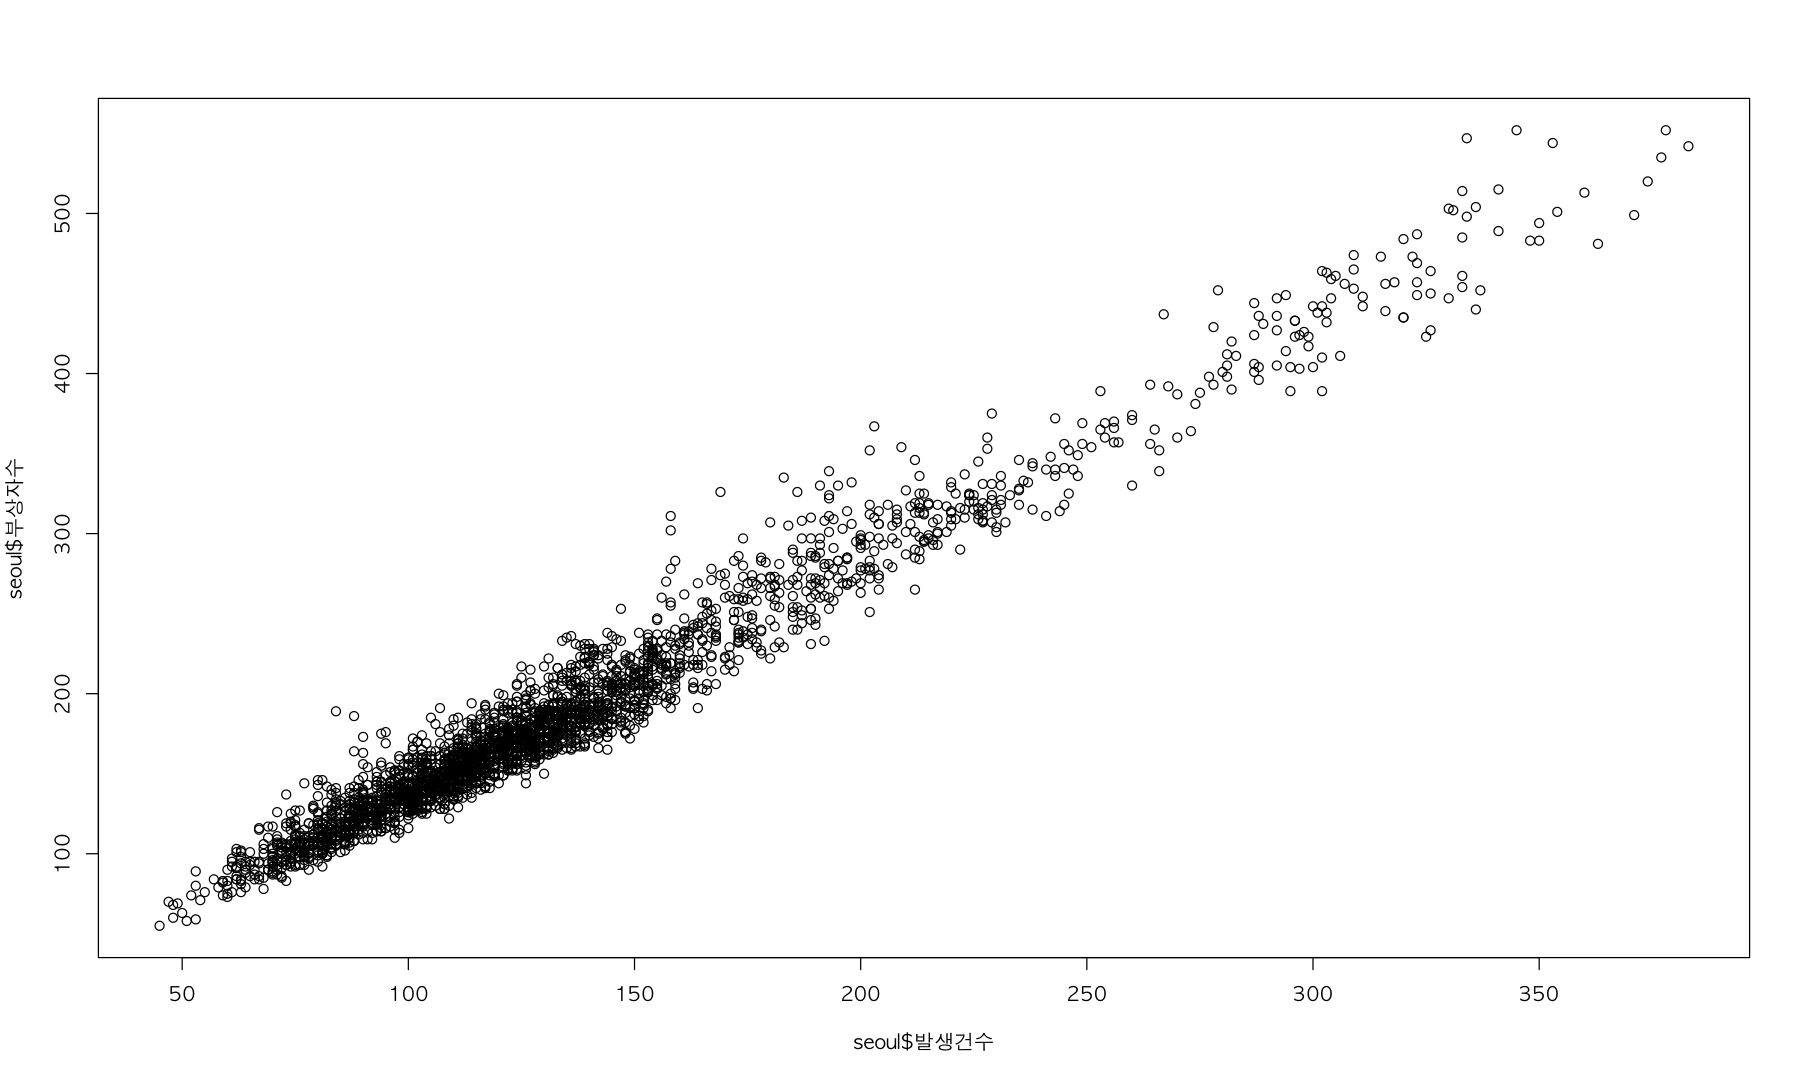

In [ ]:
#산점도
par(family = 'AppleGothic',bg='white')
plot(seoul$'발생건수',seoul$'부상자수')
#아래 쪽에 몰려있음 150미만:KNN/위쪽은 KNN 못씀